In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17227 entries, 64 to 61813
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            17227 non-null  object 
 1   country                             17227 non-null  object 
 2   contest_url                         17227 non-null  object 
 3   num_of_contest                      17227 non-null  int64  
 4   is_weekly                           17227 non-null  bool   
 5   rank                                17227 non-null  int64  
 6   score                               17227 non-null  int64  
 7   question_number                     17227 non-null  int64  
 8   question_language                   17227 non-null  object 
 9   question_code                       17227 non-null  object 
 10  number_of_lines                     17227 non-null  int64  
 11  names_set                           17227 non

<Axes: >

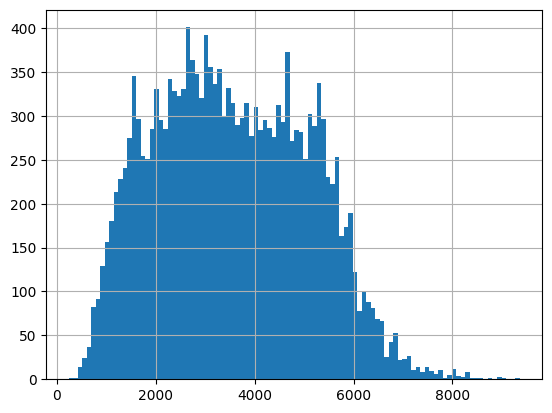

In [ ]:
leetcode_questions_df.contest_finish_time_total_seconds.hist(bins=100)

In [ ]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,1720
False,1720


In [ ]:
leetcode_questions_df = filtered_df

In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,...,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000
mean,285.179360,541.034593,16.051163,3.378779,54.972674,47.428198,23.945349,3.232267,3.758430,4.882849,...,0.049646,0.089641,0.108505,0.088174,3692.917151,2423.980814,1214.640407,0.041852,1585.792151,7.898547
std,124.726992,382.172368,2.953108,0.485153,52.781271,41.881027,22.815809,9.988877,4.331369,5.935727,...,0.040750,0.071999,0.075578,0.157392,2563.643015,1779.336745,1170.629504,0.087554,1881.008566,6.687682
min,117.000000,1.000000,8.000000,3.000000,6.000000,10.000000,4.000000,1.000000,0.000000,0.000000,...,0.007874,0.000000,0.000000,0.000000,237.000000,160.000000,0.000000,0.000001,108.000000,1.000000
25%,124.000000,140.000000,12.000000,3.000000,31.000000,30.000000,15.000000,1.000000,2.000000,2.000000,...,0.028571,0.039331,0.052632,0.000000,1207.000000,951.000000,365.000000,0.001832,840.000000,2.000000
50%,374.000000,578.000000,18.000000,3.000000,43.000000,36.000000,19.000000,1.000000,3.000000,4.000000,...,0.038462,0.080000,0.096154,0.000000,3568.000000,1440.000000,724.000000,0.008877,1204.000000,6.000000
75%,384.000000,867.000000,18.000000,4.000000,61.000000,47.250000,25.000000,2.000000,5.000000,6.000000,...,0.058824,0.120000,0.151515,0.128205,6031.000000,4396.500000,1878.250000,0.038555,1707.250000,11.000000
max,390.000000,1223.000000,20.000000,4.000000,793.000000,450.000000,291.000000,135.000000,69.000000,108.000000,...,0.589041,1.066667,0.538462,0.877551,9359.000000,5399.000000,5238.000000,0.951969,26867.000000,29.000000


In [ ]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
# from sklearn.utils import resample

# # Separate the majority and minority classes
# majority_class = X_train_text[y_train == 0]
# minority_class = X_train_text[y_train == 1]

# # Undersample the majority class
# majority_downsampled = resample(majority_class,
#                                replace=False,  # sample without replacement
#                                n_samples=len(minority_class),  # match minority class
#                                random_state=42)

# # Combine the downsampled majority class with the minority class
# X_train_text = pd.concat([majority_downsampled, minority_class]).reset_index(drop=True)
# y_train = pd.concat([pd.Series([0] * len(majority_downsampled)), pd.Series([1] * len(minority_class))]).reset_index(drop=True)

## CodeBert

In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-cpp"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at neulab/codebert-cpp and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text, y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=15,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=5e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.685900,0.644854,0.630814,0.624954,0.624954,0.639535,0.630814
2,0.591900,0.552186,0.741279,0.741014,0.741014,0.742270,0.741279
3,0.470200,0.487307,0.790698,0.790691,0.790691,0.790737,0.790698
4,0.464200,0.436802,0.796512,0.796174,0.796174,0.798489,0.796512
5,0.339900,0.418652,0.819767,0.819548,0.819548,0.821332,0.819767
6,0.361700,0.450615,0.808140,0.805236,0.805236,0.827678,0.808140
7,0.246400,0.518965,0.799419,0.799132,0.799132,0.801139,0.799419
8,0.242100,0.518159,0.819767,0.819743,0.819743,0.819940,0.819767
9,0.073800,0.790289,0.819767,0.819615,0.819615,0.820852,0.819767
10,0.117800,0.853759,0.799419,0.798928,0.798928,0.802372,0.799419


TrainOutput(global_step=760, training_loss=0.3581004074529598, metrics={'train_runtime': 1045.4096, 'train_samples_per_second': 34.551, 'train_steps_per_second': 1.09, 'total_flos': 6335714213068800.0, 'train_loss': 0.3581004074529598, 'epoch': 10.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.84      0.79      0.81       344
   high_rank       0.80      0.85      0.83       344

    accuracy                           0.82       688
   macro avg       0.82      0.82      0.82       688
weighted avg       0.82      0.82      0.82       688

f1_score_macro :  0.8195829632449351
f1_score_weighted :  0.819582963244935


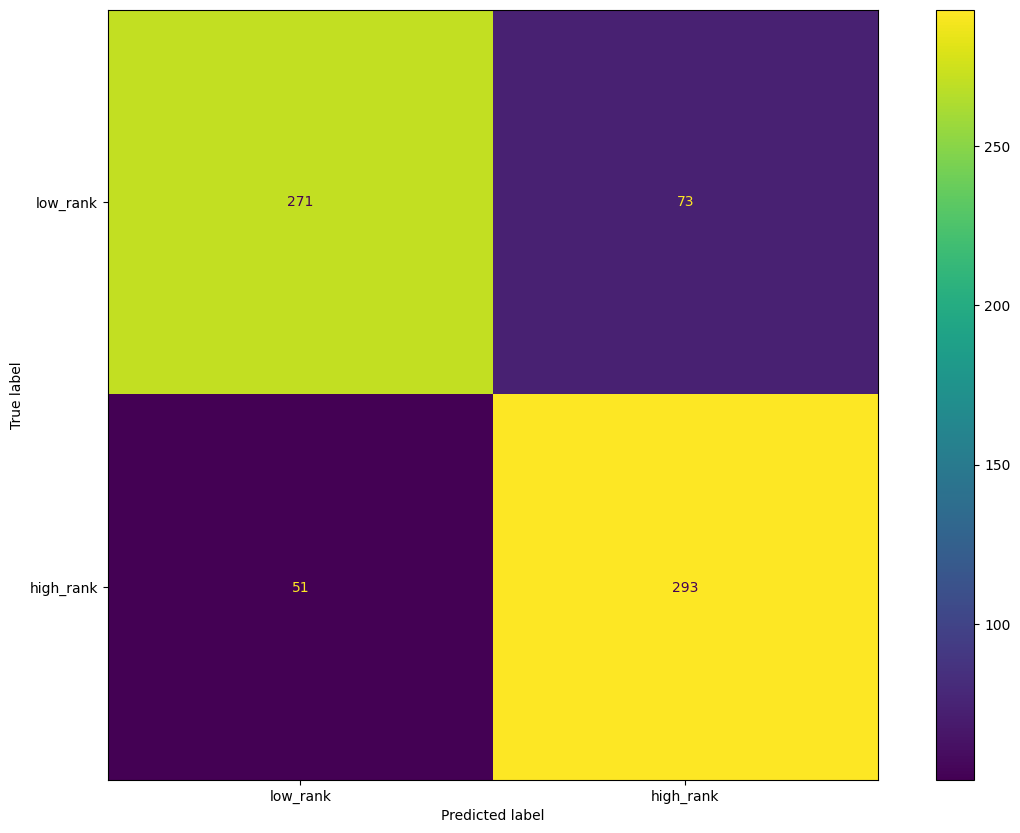

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.99      0.96      0.97      1204
   high_rank       0.96      0.99      0.97      1204

    accuracy                           0.97      2408
   macro avg       0.97      0.97      0.97      2408
weighted avg       0.97      0.97      0.97      2408

f1_score_macro :  0.9721702003315716
f1_score_weighted :  0.9721702003315715


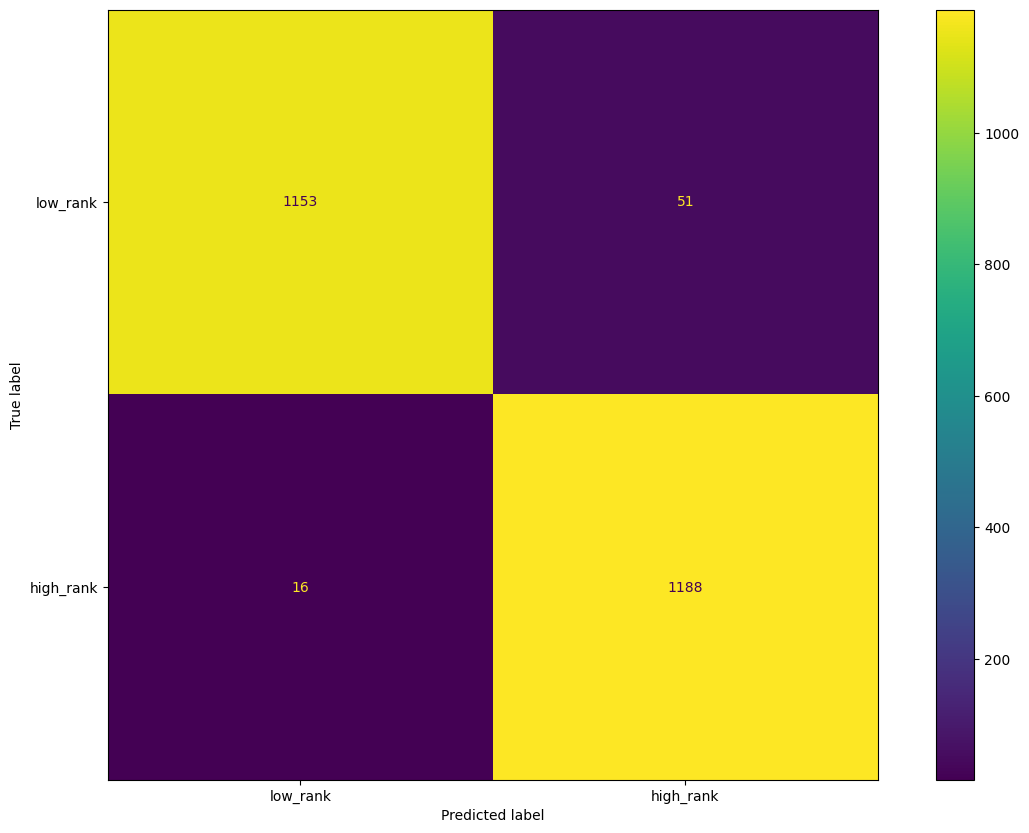

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()